# Density estimation: mixtures vs kernel density

Two philosophies for estimating an unknown probability density from samples - parametric (fit a Gaussian mixture with a few components) and nonparametric (kernel density estimation, KDE) - when each wins, and how the same bias-variance tradeoff governs both: the number of mixture components and the KDE bandwidth are the same knob under different names, tuned by held-out likelihood.


## The problem and two strategies

Density estimation seeks the density $f$ of iid data $x_1,\dots,x_n$ without assuming a single
parametric form. Two strategies compete. A parametric mixture posits
$f(x)=\sum_{k=1}^K \pi_k\,\phi(x\mid\theta_k)$ with a fixed number of components and is fit by maximum
likelihood. A nonparametric kernel density estimate (KDE) places a small bump at each observation,
$$\hat f_h(x) = \frac{1}{nh}\sum_{i=1}^n K\!\Big(\frac{x-x_i}{h}\Big),$$
where the kernel $K$ is a symmetric density and $h>0$ is the bandwidth. The bandwidth, not the kernel,
governs the bias-variance trade-off, and choosing it well is the whole game.

## Bias, variance, and the optimal bandwidth

Theorem (pointwise bias and variance of the KDE). For a twice-differentiable density $f$ and a kernel
with $\int K=1$, $\int uK(u)du=0$, $\int u^2K(u)du=\mu_2$, and $R(K)=\int K^2$,
$$\mathrm{Bias}\,\hat f_h(x) \approx \tfrac{1}{2}h^2\mu_2\,f''(x), \qquad
  \mathrm{Var}\,\hat f_h(x) \approx \frac{f(x)\,R(K)}{nh}.$$

Proof sketch. For the bias, $\mathbb E\hat f_h(x)=\int \tfrac1h K(\tfrac{x-y}{h})f(y)dy$; substitute
$u=(x-y)/h$, Taylor-expand $f(x-hu)$ to second order, and use the kernel moment conditions; the leading
correction is $\tfrac12 h^2\mu_2 f''(x)$. For the variance, $\hat f_h$ is an average of $n$ iid terms, so
$\mathrm{Var}\,\hat f_h = \tfrac1n \mathrm{Var}\big(\tfrac1h K(\tfrac{x-X}{h})\big)$; the leading term of
$\mathbb E[\tfrac1{h^2}K(\cdot)^2]$ is $f(x)R(K)/h$, giving $f(x)R(K)/(nh)$. $\quad\blacksquare$

Integrating the squared bias plus variance gives the mean integrated squared error,
$\mathrm{MISE}(h) \approx \tfrac14 h^4 \mu_2^2 R(f'') + R(K)/(nh)$. Minimizing over $h$:

Theorem (optimal bandwidth). The MISE-optimal bandwidth and the resulting error are
$$h^\star = \Big(\frac{R(K)}{\mu_2^2 R(f'')\,n}\Big)^{1/5} \propto n^{-1/5}, \qquad
  \mathrm{MISE}(h^\star) \propto n^{-4/5}.$$
Bias falls and variance rises as $h$ grows, and the two balance at $h^\star\propto n^{-1/5}$. The
nonparametric rate $n^{-4/5}$ is slower than the parametric $n^{-1}$, the price of assuming less.

Theorem (curse of dimensionality). In $d$ dimensions the optimal rate degrades to
$\mathrm{MISE}\propto n^{-4/(4+d)}$. To hold the error fixed, the sample size must grow exponentially in
$d$, which is why nonparametric density estimation is hopeless in high dimensions and structured
parametric models are needed there.

## Mixtures and identifiability

A finite mixture trades the bandwidth knob for a component-count knob $K$, fit by maximum likelihood with
EM. Its convergence rate is parametric ($n^{-1}$) when the model is correct, beating KDE, but it is
biased when $f$ is not a mixture of the assumed form.

Theorem (identifiability of finite mixtures). Mixtures of Gaussian (more generally, of any family whose
characteristic functions are linearly independent) are identifiable up to a permutation of the component
labels: two mixtures with the same density have the same components and weights, possibly reordered.

This is why fitted components are interpretable, and also why label switching (the permutation freedom)
must be handled when summarizing across runs or posterior draws.

Counterexample (non-identifiability). Mixtures of uniform distributions are not identifiable:
$\tfrac12\mathrm{Unif}(0,2)+\tfrac12\mathrm{Unif}(0,1)$ and other combinations can produce the same
density, so the components cannot be recovered. Identifiability is a property of the component family,
not of mixtures in general.

Counterexample (bandwidth extremes). Too small an $h$ gives a spiky estimate with a delta-like bump at
each point: zero bias, ruinous variance. Too large an $h$ gives a flat oversmoothed estimate: low
variance, large bias that erases real structure such as bimodality. The MISE curve below makes the
trade-off and its $n^{-1/5}$ minimizer concrete.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import GaussianEstimator, MixtureEstimator, GaussianDistribution, MixtureDistribution
from mixle.inference.estimation import optimize
from sklearn.neighbors import KernelDensity
rng = np.random.RandomState(0)

def fit_gmm(data, K, max_its=80):
    # seed component means at data quantiles so EM starts spread out; random
    # initialization can otherwise collapse all components to a symmetric saddle
    data = [float(v) for v in data]
    qs = np.quantile(data, np.linspace(0.1, 0.9, K)); sd = float(np.std(data))
    seed = MixtureDistribution([GaussianDistribution(float(q), sd) for q in qs], [1.0 / K] * K)
    return optimize(data, MixtureEstimator([GaussianEstimator()] * K), max_its=max_its,
                    prev_estimate=seed, print_iter=100)

## 1. The problem and the true density

We are handed samples and want the density that generated them - to detect anomalies, simulate, or just understand the shape. Our ground truth is a deliberately non-Gaussian mixture (a tall narrow peak beside a broad bump) so that no single Gaussian can fit it, and we hold out a test set to score honestly.


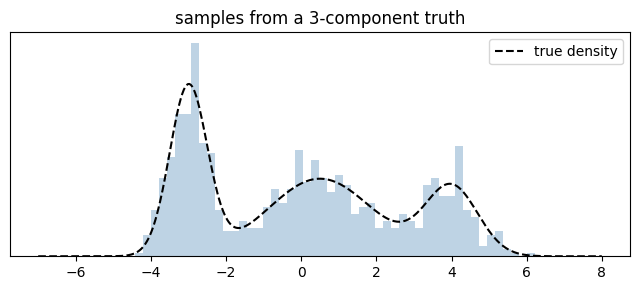

In [2]:
# true density: a 3-component Gaussian mixture
centers, sds, w = [-3.0, 0.5, 4.0], [0.5, 1.4, 0.7], [0.35, 0.45, 0.20]
def sample(n):
    k = rng.choice(3, size=n, p=w)
    return rng.normal(np.array(centers)[k], np.array(sds)[k])
def true_pdf(x):
    return sum(wi * np.exp(-0.5 * ((x - c) / s) ** 2) / (s * np.sqrt(2 * np.pi))
               for c, s, wi in zip(centers, sds, w))

train, test = sample(800), sample(2000)
grid = np.linspace(-7, 8, 400)
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(train, bins=50, density=True, alpha=0.35, color='steelblue')
ax.plot(grid, true_pdf(grid), 'k--', lw=1.5, label='true density')
ax.set_title('samples from a 3-component truth'); ax.legend(); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 2. Two estimators

Parametric - Gaussian mixture. Assume the density is a sum of $K$ Gaussians and fit their means, variances, and weights by EM. Few parameters, smooth, extrapolates - but biased if $K$ is too small.

Nonparametric - KDE. Place a small kernel (a mini-Gaussian of width = bandwidth $h$) on every data point and sum. No shape assumption, arbitrarily flexible - but high variance and it cannot extrapolate beyond the data.

We fit a $K=3$ mixture and a KDE, and overlay both on the truth.


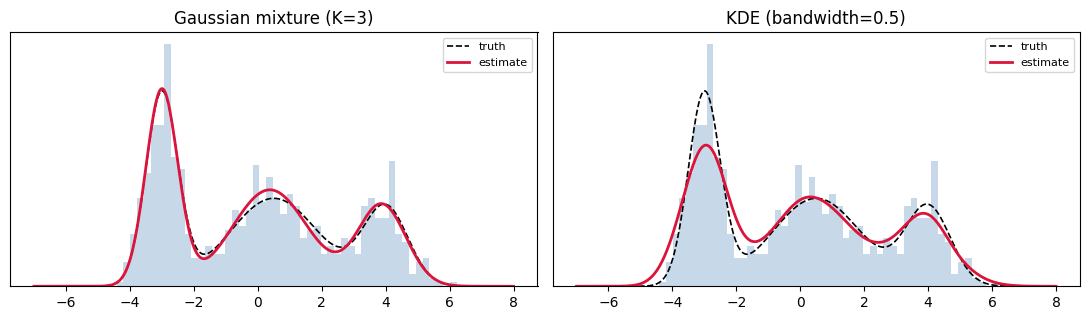

In [3]:
gmm = fit_gmm(train, 3)
gmm_pdf = np.exp([gmm.log_density(float(x)) for x in grid])

kde = KernelDensity(bandwidth=0.5).fit(train[:, None])
kde_pdf = np.exp(kde.score_samples(grid[:, None]))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3), sharey=True)
for a, pdf, ttl in zip(ax, [gmm_pdf, kde_pdf], ['Gaussian mixture (K=3)', 'KDE (bandwidth=0.5)']):
    a.hist(train, bins=50, density=True, alpha=0.3, color='steelblue')
    a.plot(grid, true_pdf(grid), 'k--', lw=1.2, label='truth')
    a.plot(grid, pdf, 'crimson', lw=2, label='estimate'); a.set_title(ttl); a.legend(fontsize=8); a.set_yticks([])
plt.tight_layout(); plt.show()

## 3. The same bias-variance knob

Too few components (or too large a bandwidth) underfits - high bias, the estimate is too smooth to capture the peaks. Too many components (or too small a bandwidth) overfits - high variance, the estimate chases noise. The principled way to choose either is held-out log-likelihood: score the fitted density on data it never saw. We sweep $K$ for the mixture and the bandwidth for KDE and watch both trace the characteristic inverted-U.


Iteration 3: ln[p_mat(Data|Model)]=-1.938073e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
Iteration 43: ln[p_mat(Data|Model)]=-1.761603e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=5.211405e-10


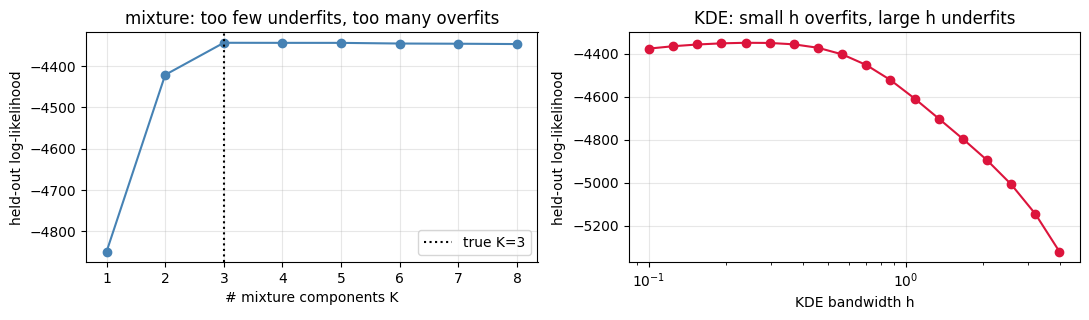

best K=3 ; best bandwidth=0.24


In [4]:
tr = [float(x) for x in train]
Ks = range(1, 9)
gmm_test_ll = []
for K in Ks:
    m = fit_gmm(tr, K)
    gmm_test_ll.append(float(np.sum(m.seq_log_density(m.dist_to_encoder().seq_encode([float(x) for x in test])))))

bws = np.logspace(-1, 0.6, 18)
kde_test_ll = [KernelDensity(bandwidth=h).fit(train[:, None]).score(test[:, None]) for h in bws]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].plot(list(Ks), gmm_test_ll, 'o-', color='steelblue'); ax[0].axvline(3, color='k', ls=':', label='true K=3')
ax[0].set_xlabel('# mixture components K'); ax[0].set_ylabel('held-out log-likelihood'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title('mixture: too few underfits, too many overfits')
ax[1].semilogx(bws, kde_test_ll, 'o-', color='crimson')
ax[1].set_xlabel('KDE bandwidth h'); ax[1].set_ylabel('held-out log-likelihood'); ax[1].grid(alpha=0.3)
ax[1].set_title('KDE: small h overfits, large h underfits')
plt.tight_layout(); plt.show()
print('best K=%d ; best bandwidth=%.2f' % (list(Ks)[int(np.argmax(gmm_test_ll))], bws[int(np.argmax(kde_test_ll))]))

## Data-driven bandwidth selection

The KDE bandwidth is the whole ballgame, and Silverman's rule of thumb over-smooths multimodal data. The modern defaults select it from the data - by likelihood cross-validation or the Sheather-Jones plug-in. We compare Silverman's rule to a CV-selected bandwidth and confirm CV picks a smaller, less-biased bandwidth on our multimodal density.


In [5]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
tr = np.asarray(train).reshape(-1, 1)
silverman = 1.06 * tr.std() * len(tr) ** (-1 / 5.0)          # rule of thumb
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                    {'bandwidth': np.linspace(0.1, 1.5, 30)}, cv=5).fit(tr)
cv_bw = grid.best_params_['bandwidth']
score = lambda bw: KernelDensity(bandwidth=bw).fit(tr).score(np.asarray(test).reshape(-1, 1))
print('Silverman rule-of-thumb bandwidth: %.3f   held-out LL=%.1f' % (silverman, score(silverman)))
print('cross-validated bandwidth        : %.3f   held-out LL=%.1f  <- less biased on multimodal data'
      % (cv_bw, score(cv_bw)))

Silverman rule-of-thumb bandwidth: 0.760   held-out LL=-4474.4
cross-validated bandwidth        : 0.245   held-out LL=-4348.1  <- less biased on multimodal data


## Illustration: the MISE trade-off and the n^(-1/5) bandwidth

We estimate the integrated squared error of a Gaussian-kernel KDE across bandwidths for samples from a
known density, average over replications, and read off the minimizing bandwidth. Repeating across sample
sizes confirms the optimal bandwidth shrinks like $n^{-1/5}$, the rate the theorem predicts.

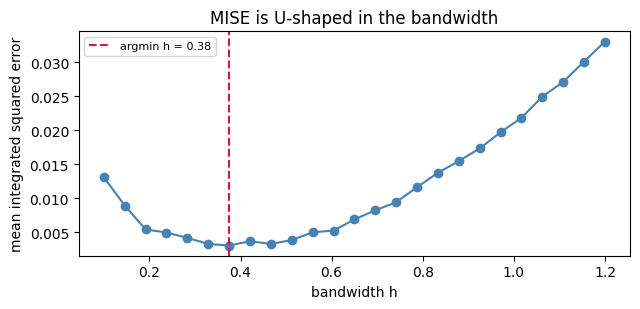

 n      optimal bandwidth     n^(-1/5) scaled


   100        0.421               0.421


   400        0.421               0.319


  1600        0.237               0.242


  6400        0.192               0.183
the optimal bandwidth tracks the n^(-1/5) prediction.


In [6]:
from scipy.stats import norm
rng = np.random.RandomState(0)
grid = np.linspace(-5, 5, 400); f_true = norm.pdf(grid)
def kde(x, h, grid):
    return np.mean(norm.pdf((grid[:, None] - x[None, :]) / h) / h, axis=1)
def mean_ise(n, h, reps=60):
    vals = []
    for _ in range(reps):
        x = rng.normal(0, 1, n)
        vals.append(np.trapezoid((kde(x, h, grid) - f_true) ** 2, grid))
    return np.mean(vals)
n = 200; hs = np.linspace(0.1, 1.2, 25)
ise = [mean_ise(n, h) for h in hs]
h_star = hs[int(np.argmin(ise))]
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(hs, ise, 'o-', color='steelblue'); ax.axvline(h_star, color='crimson', ls='--', label='argmin h = %.2f' % h_star)
ax.set_xlabel('bandwidth h'); ax.set_ylabel('mean integrated squared error'); ax.legend(fontsize=8)
ax.set_title('MISE is U-shaped in the bandwidth'); plt.tight_layout(); plt.show()
print(' n      optimal bandwidth     n^(-1/5) scaled')
ref = None
for n in [100, 400, 1600, 6400]:
    hh = np.linspace(0.1, 1.2, 25); h_opt = hh[int(np.argmin([mean_ise(n, h, reps=40) for h in hh]))]
    if ref is None: ref = h_opt * 100 ** 0.2
    print(' %5d        %.3f               %.3f' % (n, h_opt, ref * n ** -0.2))
print('the optimal bandwidth tracks the n^(-1/5) prediction.')

## References

- Silverman, B. W. (1986). Density Estimation for Statistics and Data Analysis. Chapman & Hall. - the standard KDE reference (rule-of-thumb bandwidth).
- Sheather, S. J. & Jones, M. C. (1991). A reliable data-based bandwidth selection method for KDE (https://doi.org/10.1111/j.2517-6161.1991.tb01857.x). JRSS-B 53(3), 683-690.
- Scott, D. W. (2015). Multivariate Density Estimation, 2nd ed. Wiley. - the curse of dimensionality for KDE.
- McLachlan, G. & Peel, D. (2000). Finite Mixture Models. Wiley.
- Wasserman, L. (2006). All of Nonparametric Statistics. Springer.


## Exercises and extensions

1. Bandwidth selection shoot-out. Implement three KDE bandwidth rules - Silverman's rule of thumb, Sheather-Jones plug-in, and leave-one-out likelihood CV - and compare on data of varying smoothness and sample size by integrated squared error to a known truth. Reproduce the known result that the rule of thumb over-smooths multimodal densities.
2. Curse of dimensionality. Fix the data-generating mixture and grow the dimension from 1 to 10. Track held-out log-likelihood for a fitted Gaussian mixture vs KDE; show the parametric model degrades gracefully while KDE's effective sample size collapses (Scott). Quantify the dimension at which KDE becomes useless for your $n$.
3. Adaptive / variable-bandwidth KDE. Implement a balloon or sample-point adaptive KDE (bandwidth scales with local density) and show it beats fixed-bandwidth KDE on data with both a sharp peak and a heavy tail.
4. Density estimation for anomaly detection. Use both a mixture and a KDE as the density model in anomaly_detection; compare ROC/AUC for detecting tail outliers and discuss why the parametric tail behavior matters.
